# **Directed percolation in Rust-Python**

Demo simulation of directed percolation on a 2d lattice.

<hr>

## Preliminaries

In [1]:
from essentials import *

<hr>

## Parameters

In [ ]:
class Parameters:
    p: float = 0.163145
    p0: float = 0.99
    seed: int = 1
    n_iterations: int = 1_000
    sample_rate: int  = 1_000
    dim = sim.Dimension.D2
    n_x: int = 10_000
    n_y: int = 10_000
    n_z: int = 1
    axis_topology_x = sim.Topology.Periodic
    axis_topology_y = sim.Topology.Periodic
    axis_topology_z = sim.Topology.Unspecified
    axis_bcs_x = (sim.BoundaryCondition.Floating, sim.BoundaryCondition.Floating)
    axis_bcs_y = (sim.BoundaryCondition.Floating, sim.BoundaryCondition.Floating)
    axis_bcs_z = (sim.BoundaryCondition.Unspecified, sim.BoundaryCondition.Unspecified)
    axis_bc_values_x = (True, True)
    axis_bc_values_y = (True, True)
    axis_bc_values_z = (False, False)
    do_edge_buffering: bool = True
    processing = sim.Processing.Parallel
    n_threads: int = 16
parameters = Parameters()
# Just in case we forget to update sample_rate to match n_iterations
if parameters.sample_rate > parameters.n_iterations:
    parameters.sample_rate = parameters.n_iterations

<hr>

## Simulation

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [3]:
n_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: list[list, list]
t_run_time: float

In [4]:
(n_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dp(parameters)
print(f"Total number of lattice time slices = {n_lattices}\n")


Probability: 0.163145
Prob @t=0:   0.99
Random seed: 1
Iterations:  10000
Sample rate: 10000
Dimension:   D2
Grid shape:  (10000, 10000, 1)
Topology x:  Periodic
Total number of lattice time slices = 2

Topology y:  Periodic
Topology z:  Unspecified
Axis BCs x:  (Floating, Floating)
Axis BCs y:  (Floating, Floating)
Axis BCs z:  (Unspecified, Unspecified)
BC values x: (true, true)
BC values y: (true, true)
BC values z: (false, false)
Edge buffer: true
Processing:  Parallel
Num threads: 16

Simulation run time (parallel processing): 437.735s


<hr>

## Post-processing

The function `sim.dp` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all them concatenated into one long 1d list.

We convert this long list into a 2+1d numpy array, with the last index being the lattice slice number. Care must be taken to reshape by the grid dimensions in the correct order: the fastest index in the list is the x coordinate, etc., so the reshaping parameters need to be given in reverse order `(n_lattices, y, x)`.

In [5]:
lattices: NDArray = np.array(raw_lattices, dtype=np.bool,).reshape(
    n_lattices, parameters.n_y, parameters.n_x,
    ).T
lattices.shape

(10000, 10000, 2)

Tracking data, which for now is the vector pair (t; mean ρ):

In [6]:
tracking: NDArray = np.array(raw_tracking, dtype=np.float64,) 
tracking.shape

(2, 10001)

<hr>

## Visualization

In [7]:
viz = Viz(dpi=100)
i_slice: int
name: str

In [27]:
image_lattice = partial(
    viz.image_lattice,
    lattices=lattices, 
    p=parameters, 
    x=300,
    y=200,
    fig_size=(6, 4,),
)

Visualize the initial lattice:

lattice_p0p163145_s1_nx10000_ny10000_i00000


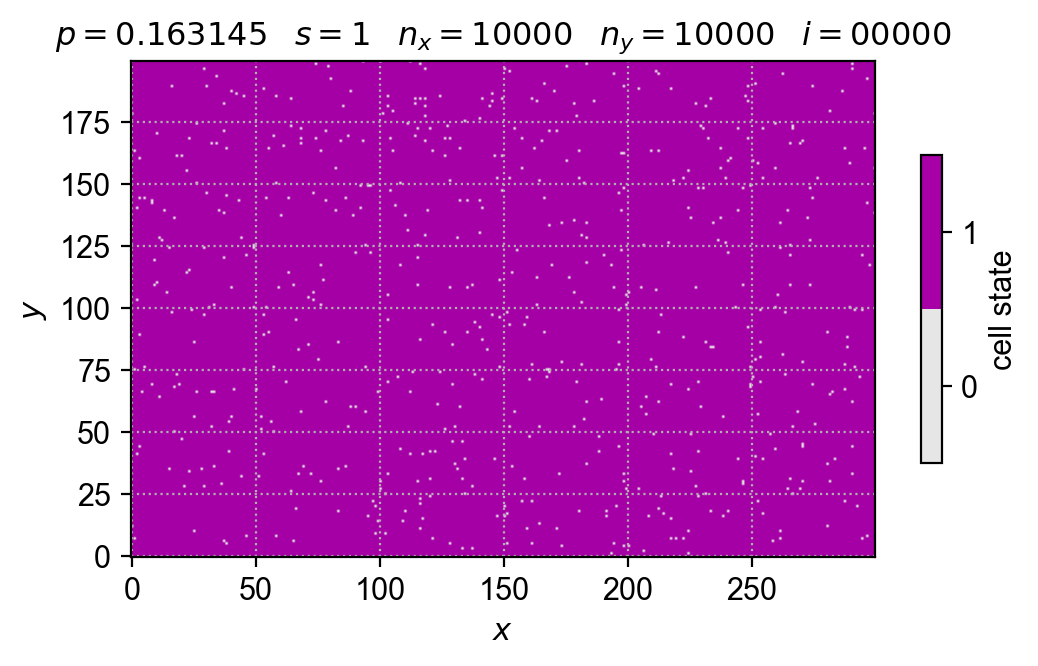

In [9]:
i_slice = 0
name = make_name(parameters, "lattice", i_slice,)
print(name)
image_lattice(
    name=name, title=make_title(parameters, i_slice), i_lattice=i_slice,
)
plt.show()

Visualize the final lattice:

lattice_p0p163145_s1_nx10000_ny10000_i10000


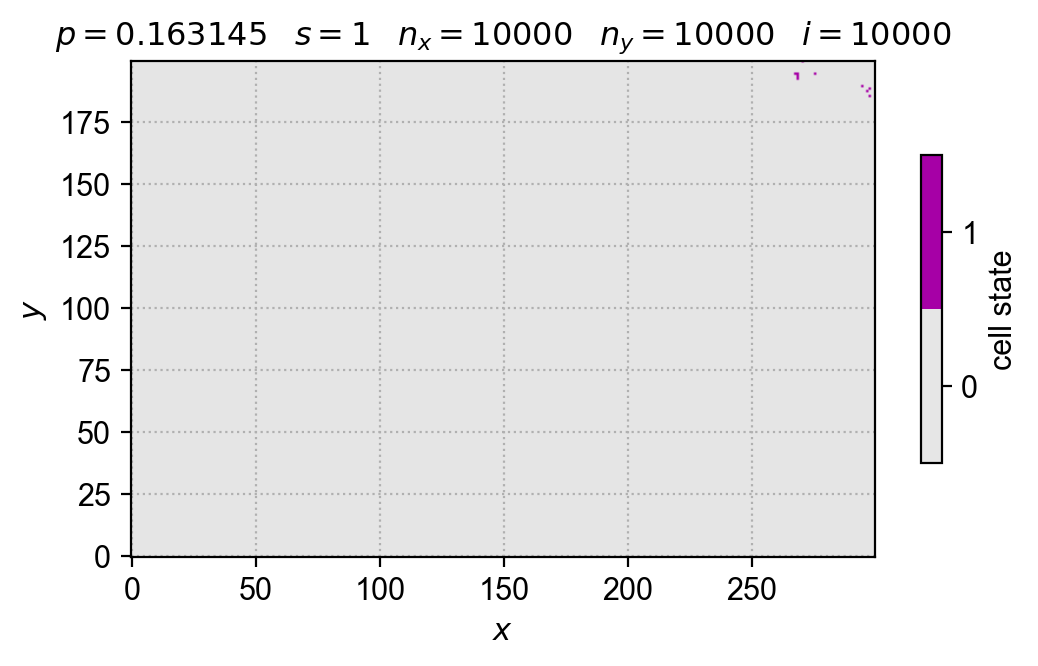

In [10]:
i_slice = (n_lattices-1)
name = make_name(parameters, "lattice", i_slice,)
print(name)
image_lattice(
    name=name, title=make_title(parameters, i_slice), i_lattice=i_slice,
)
plt.show()

See Henkel et al (2008), tables 4.1 and 4.3: the decay rate of the mean order parameter (mean occupancy) $\overline\rho$ should decay with time as
$$
    \rho(t) \sim t^{-\delta}
$$
where $\delta \approx 0.4505$. If that's what we're seeing, there's a long "burn-in" phase. It appears we're a bit off the ideal value: (1) because there is a finite lattice-size bias; and (2) because we need to extremely precise about choosing $p=p_c$. 

Here I have heuristically tuned $p$ to
$$
    p_c =? \,\,0.163145
$$
which is rather far off any traditional critical DP probability $p_c$, probably because of the 9-cell neighborhood live/die dependency.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ρmean_p0p163145_s1_nx10000_ny10000


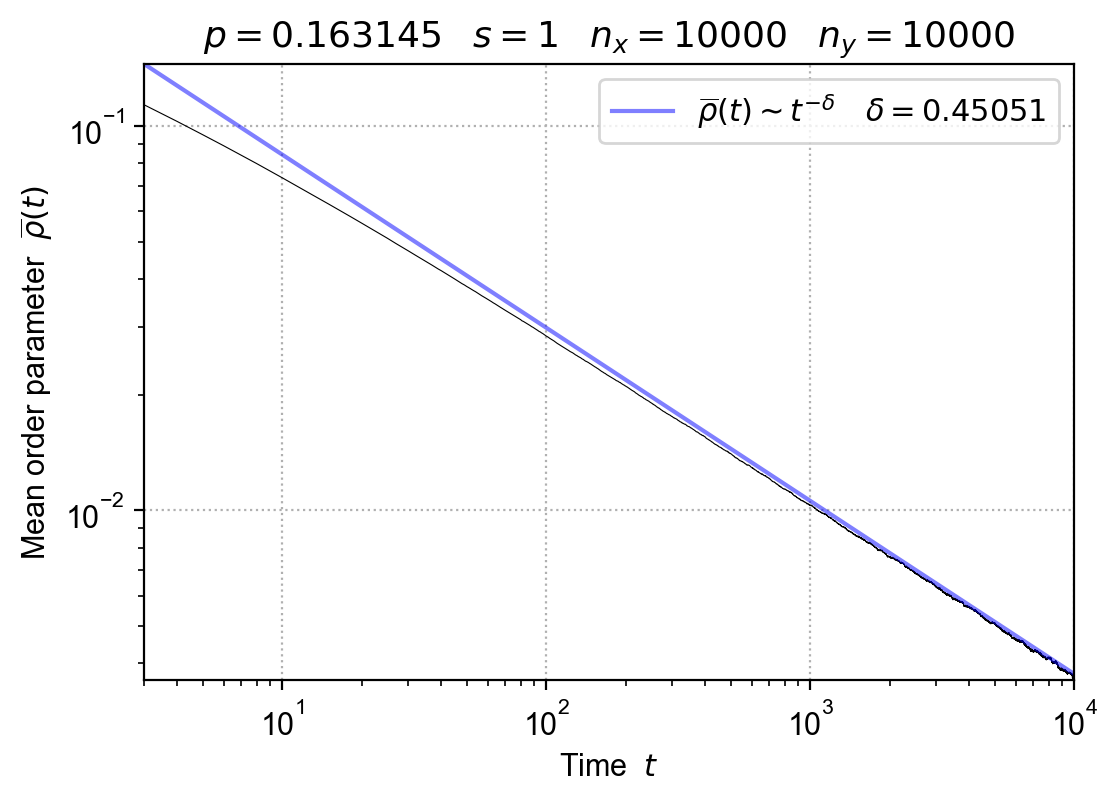

In [14]:
δ = 0.45051
ρ_mean_ref = 0.238

name = make_name(parameters, "ρmean", None, )
print(name)
viz.plot_ρmean(
    name,
    make_title(parameters, None),
    tracking,
    δ, 
    ρ_mean_ref,
    fig_size=(6,4,),
)

In [ ]:
i_offset: int = parameters.n_iterations//3
t: NDArray = tracking[0][i_offset:]
ρ_mean: NDArray = tracking[1][i_offset:]
(exponent, scale, r_value, p_value, std_err) \
    = linregress(np.log(t), np.log(ρ_mean))

print(rf"Estimated t-decay exponent:  δ = {exponent:0.3f}")

Estimated t-decay exponent:  δ = -0.449


<hr>

## Export

In [13]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "dp2d")
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots/dp2d'